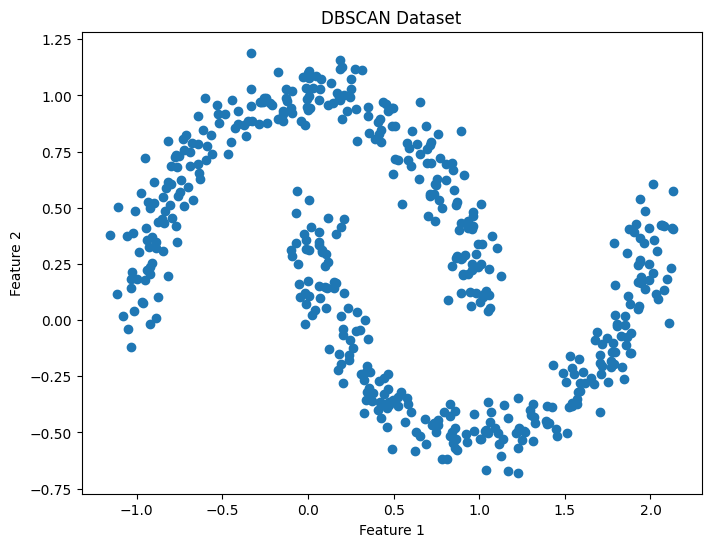

Unique labels: [0 1]
Number of clusters: 2
Number of noise points: 0


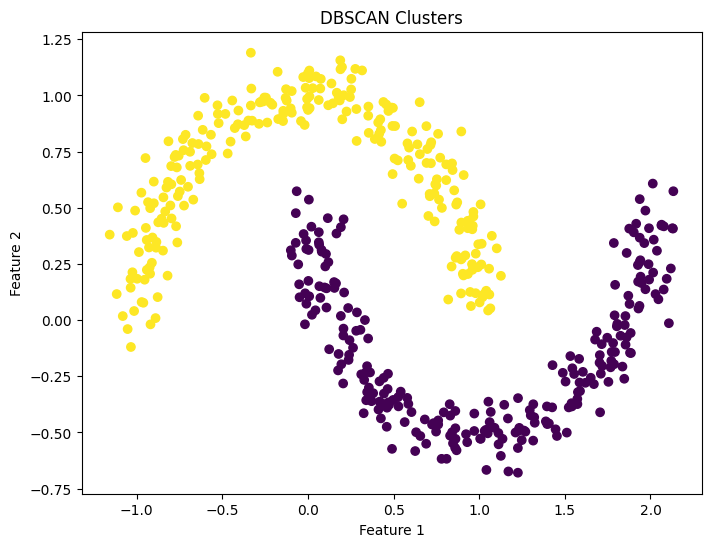

eps=0.1: clusters=3, noise=22
eps=0.15: clusters=2, noise=2
eps=0.2: clusters=2, noise=0
eps=0.3: clusters=1, noise=0
eps=0.5: clusters=1, noise=0
min_samples=3: clusters=2, noise=0
min_samples=5: clusters=2, noise=0
min_samples=10: clusters=2, noise=0
min_samples=20: clusters=2, noise=3


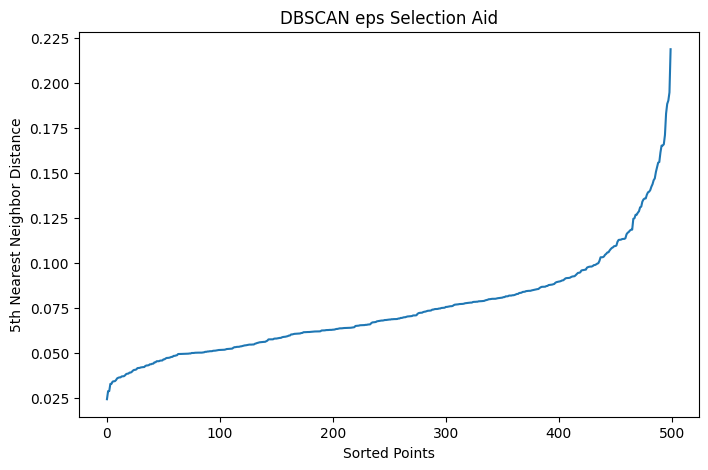


Manhattan metric labels: [0 1]

Scaled DBSCAN labels: [-1  0  1]

Silhouette score excluding noise: 0.33057612844631057


In [1]:
# ============================================================
# DBSCAN 🟡
# ============================================================
#
# DEPTH:
#   🟡 Medium
#
# Learn:
#   1. Why DBSCAN?
#   2. Intuition
#   3. Density
#   4. eps
#   5. min_samples
#   6. Core / Border / Noise points
#   7. Internal working
#   8. sklearn implementation
#   9. Important parameters
#  10. Choosing eps
#  11. Scaling
#  12. DBSCAN vs K-Means
#  13. DBSCAN vs Hierarchical
#  14. DBSCAN vs GMM
#  15. Interview questions
#  16. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import silhouette_score


# ============================================================
# 2. WHY DBSCAN?
# ============================================================
#
# K-Means has some important limitations:
#
#     1. We need to specify K.
#
#     2. It works best with roughly spherical clusters.
#
#     3. It is sensitive to outliers.
#
#
# DBSCAN solves some of these problems by looking at
# DENSITY instead of centroids.
#
#
# DBSCAN can:
#
#     ✓ Discover the number of clusters automatically
#     ✓ Find irregular-shaped clusters
#     ✓ Identify noise/outliers
#
# ============================================================


# ============================================================
# 3. CORE INTUITION ⭐⭐⭐
# ============================================================
#
# Imagine points arranged like this:
#
#
#       ● ● ●
#      ● ● ● ●
#       ● ● ●
#
#
#                         ●
#
#
#                              ○ ○
#                             ○ ○ ○
#                              ○ ○
#
#
# DBSCAN asks:
#
#     "Where are there enough points packed closely together?"
#
#
# Dense region:
#
#     → cluster
#
#
# Sparse isolated point:
#
#     → noise
#
#
# This is the key idea:
#
#             DENSITY
#
# ============================================================


# ============================================================
# 4. WHAT DOES "DENSITY" MEAN?
# ============================================================
#
# We define a neighborhood around every point.
#
#
# Example:
#
#                ●
#             ●  X  ●
#                ●
#
#
# X has many nearby points.
#
# Therefore:
#
#     X is in a dense region.
#
#
# DBSCAN controls this using TWO parameters:
#
#
#     eps
#     min_samples
#
# ============================================================


# ============================================================
# 5. EPSILON (eps) ⭐⭐⭐
# ============================================================
#
# eps defines the radius of the neighborhood.
#
#
# Imagine:
#
#
#             . - - - .
#          .             .
#        .       X         .
#          .             .
#             . - - - .
#
#
# Everything inside this radius is considered a neighbor.
#
#
# Small eps:
#
#     Very small neighborhood
#
#     → many points may be considered noise.
#
#
# Large eps:
#
#     Large neighborhood
#
#     → separate clusters may get merged.
#
# ============================================================


# ============================================================
# 6. min_samples ⭐⭐⭐
# ============================================================
#
# min_samples specifies the minimum number of points required
# inside a point's eps-neighborhood for it to be considered
# sufficiently dense.
#
#
# Example:
#
#     eps = 0.5
#     min_samples = 5
#
#
# A point needs enough nearby points within radius 0.5
# to qualify as a CORE point.
#
#
# IMPORTANT:
#
# sklearn's min_samples includes the point itself.
#
# ============================================================


# ============================================================
# 7. THREE TYPES OF POINTS ⭐⭐⭐
# ============================================================
#
# DBSCAN classifies points conceptually as:
#
#
# 1. CORE POINT
#
# Has at least min_samples points in its eps-neighborhood.
#
#
# 2. BORDER POINT
#
# Does not itself have enough neighbors to be a core point,
# but lies within eps of a core point.
#
#
# 3. NOISE POINT
#
# Is not a core point and is not reachable from a core point.
#
#
# ============================================================


# ============================================================
# 8. VISUAL INTUITION
# ============================================================
#
#
#              ● ● ●
#            ● ● C ●
#              ● ●
#
#
# C = CORE
#
# It has many nearby points.
#
#
#                 B
#                 ●
#
# B = BORDER
#
# It is close to a core point but doesn't have enough
# neighbors itself.
#
#
#                           X
#
# X = NOISE
#
# It is isolated.
#
# ============================================================


# ============================================================
# 9. INTERNAL WORKING ⭐⭐⭐
# ============================================================
#
# DBSCAN roughly works like this:
#
#
# STEP 1
#
# Pick an unvisited point.
#
#
# STEP 2
#
# Find all points within eps.
#
#
# STEP 3
#
# Check number of neighbors.
#
#
# If:
#
#     neighbors >= min_samples
#
#
# Then:
#
#     CORE POINT
#
#     Start a cluster.
#
#
# STEP 4
#
# Expand the cluster by exploring neighboring points.
#
#
# If a neighboring point is also core:
#
#     Add its neighbors too.
#
#
# Continue expanding.
#
#
# STEP 5
#
# If a point is close to a core point but isn't itself core:
#
#     BORDER POINT
#
#
# STEP 6
#
# If a point cannot be connected to any dense region:
#
#     NOISE
#
# ============================================================


# ============================================================
# 10. CLUSTER EXPANSION ⭐⭐⭐
# ============================================================
#
#
#                  CORE
#                   ●
#                /  |  \
#              ●    ●    ●
#             /           \
#            ●             ●
#
#
# Start with the first core point.
#
# Its neighbors become candidates.
#
# If those candidates are also core points:
#
#     expand again.
#
#
# This creates a connected dense region.
#
# ============================================================


# ============================================================
# 11. DBSCAN DOES NOT USE CENTROIDS
# ============================================================
#
# This is a major difference from K-Means.
#
#
# K-Means:
#
#     Cluster = represented by centroid.
#
#
# DBSCAN:
#
#     Cluster = connected dense region.
#
#
# Therefore DBSCAN can find shapes like:
#
#
#       ● ● ●
#      ●     ●
#      ●     ●
#       ● ● ●
#
#
# even though there isn't necessarily a useful single
# centroid-based representation.
#
# ============================================================


# ============================================================
# 12. CREATE NON-SPHERICAL DATA
# ============================================================
#
# make_moons creates two curved clusters.
#
# This is a classic example where K-Means can struggle.
#
# ============================================================

X, y = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)


# ============================================================
# 13. VISUALIZE DATA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "DBSCAN Dataset"
)

plt.show()


# ============================================================
# 14. BASIC DBSCAN
# ============================================================

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = dbscan.fit_predict(X)


# ============================================================
# 15. UNDERSTAND LABELS
# ============================================================
#
# DBSCAN uses:
#
#     0, 1, 2, ...
#
# for clusters.
#
#
# IMPORTANT:
#
#     -1 means NOISE.
#
# ============================================================

print(
    "Unique labels:",
    np.unique(labels)
)


# ============================================================
# 16. NUMBER OF CLUSTERS
# ============================================================

cluster_labels = set(labels)

n_clusters = len(
    cluster_labels - {-1}
)

print(
    "Number of clusters:",
    n_clusters
)


# ============================================================
# 17. NUMBER OF NOISE POINTS
# ============================================================

n_noise = np.sum(
    labels == -1
)

print(
    "Number of noise points:",
    n_noise
)


# ============================================================
# 18. VISUALIZE DBSCAN RESULT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "DBSCAN Clusters"
)

plt.show()


# ============================================================
# 19. IMPORTANT PARAMETER: eps ⭐⭐⭐
# ============================================================
#
# eps is probably the most important DBSCAN parameter.
#
#
# Too SMALL:
#
#     Few neighbors
#          ↓
#     Many points become noise
#          ↓
#     Clusters may fragment
#
#
# Too LARGE:
#
#     Many neighbors
#          ↓
#     Separate clusters may merge
#          ↓
#     Too few clusters
#
# ============================================================


# ============================================================
# 20. EXPERIMENT WITH eps
# ============================================================

eps_values = [
    0.1,
    0.15,
    0.2,
    0.3,
    0.5
]

for eps_value in eps_values:

    model = DBSCAN(
        eps=eps_value,
        min_samples=5
    )

    current_labels = model.fit_predict(X)

    n_clusters = len(
        set(current_labels) - {-1}
    )

    n_noise = np.sum(
        current_labels == -1
    )

    print(
        f"eps={eps_value}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise}"
    )


# ============================================================
# 21. IMPORTANT PARAMETER: min_samples ⭐⭐⭐
# ============================================================
#
# min_samples controls how many points are required for
# a dense region.
#
#
# Small min_samples:
#
#     Easier to become a core point.
#
#     → more clusters / less noise potentially.
#
#
# Large min_samples:
#
#     Harder to become a core point.
#
#     → more noise potentially.
#
#
# It also affects how conservative the density definition is.
#
# ============================================================


# ============================================================
# 22. EXPERIMENT WITH min_samples
# ============================================================

min_samples_values = [
    3,
    5,
    10,
    20
]

for min_samples in min_samples_values:

    model = DBSCAN(
        eps=0.2,
        min_samples=min_samples
    )

    current_labels = model.fit_predict(X)

    n_clusters = len(
        set(current_labels) - {-1}
    )

    n_noise = np.sum(
        current_labels == -1
    )

    print(
        f"min_samples={min_samples}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise}"
    )


# ============================================================
# 23. CHOOSING eps ⭐⭐⭐
# ============================================================
#
# A common approach:
#
#     Use a k-nearest-neighbor distance plot.
#
#
# Basic idea:
#
# For each point:
#
#     Find distance to its kth nearest neighbor.
#
#
# Sort those distances.
#
# Look for a noticeable change / knee.
#
# This can provide a candidate eps value.
#
#
# It is NOT an automatic guarantee of the perfect eps.
#
# Domain knowledge and validation still matter.
#
# ============================================================


# ============================================================
# 24. K-NEAREST-NEIGHBOR DISTANCE PLOT
# ============================================================

neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors.fit(X)

distances, indices = neighbors.kneighbors(X)


# Take distance to the 5th nearest neighbor.
k_distances = distances[:, -1]

k_distances = np.sort(
    k_distances
)


plt.figure(figsize=(8, 5))

plt.plot(
    k_distances
)

plt.xlabel(
    "Sorted Points"
)

plt.ylabel(
    "5th Nearest Neighbor Distance"
)

plt.title(
    "DBSCAN eps Selection Aid"
)

plt.show()


# ============================================================
# 25. WHY THIS PLOT HELPS
# ============================================================
#
# We are looking for a "knee" where distances start increasing
# rapidly.
#
#
# Conceptually:
#
#
# Distance
#   │
#   │
#   │                  /
#   │                /
#   │              /
#   │            /
#   │___________/
#   │
#   └──────────────────── points
#              ↑
#            knee
#
#
# A value around the knee can be a candidate for eps.
#
# ============================================================


# ============================================================
# 26. DISTANCE METRIC ⭐⭐
# ============================================================
#
# DBSCAN can use different distance metrics.
#
# Common examples:
#
#     euclidean
#     manhattan
#     cosine
#
#
# The choice depends on the data.
#
#
# Example:
#
# Numerical geometric data:
#
#     Euclidean may be natural.
#
#
# Text/vector data:
#
#     Cosine distance may be useful.
#
# ============================================================


# ============================================================
# 27. USING A DIFFERENT METRIC
# ============================================================

dbscan_manhattan = DBSCAN(
    eps=0.3,
    min_samples=5,
    metric="manhattan"
)

labels_manhattan = dbscan_manhattan.fit_predict(X)

print(
    "\nManhattan metric labels:",
    np.unique(labels_manhattan)
)


# ============================================================
# 28. FEATURE SCALING ⭐⭐⭐
# ============================================================
#
# DBSCAN is distance-based.
#
# Therefore feature scale can dramatically affect the
# neighborhood calculation.
#
#
# Example:
#
#     Age       = 20 to 60
#     Salary    = 20,000 to 200,000
#
#
# Salary can dominate the distance.
#
#
# StandardScaler can help when features are on different
# scales and standardization is appropriate.
#
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

dbscan_scaled = DBSCAN(
    eps=0.2,
    min_samples=5
)

scaled_labels = dbscan_scaled.fit_predict(
    X_scaled
)

print(
    "\nScaled DBSCAN labels:",
    np.unique(scaled_labels)
)


# ============================================================
# 29. DBSCAN + SILHOUETTE SCORE
# ============================================================
#
# Silhouette score can be used to evaluate clustering when
# there are at least two actual clusters.
#
# IMPORTANT:
#
# Noise points (-1) are usually excluded from this example
# because they are not normal cluster assignments.
#
# ============================================================

mask = labels != -1

if (
    len(np.unique(labels[mask])) >= 2
    and np.sum(mask) > 1
):

    score = silhouette_score(
        X[mask],
        labels[mask]
    )

    print(
        "\nSilhouette score excluding noise:",
        score
    )


# ============================================================
# 30. DBSCAN vs K-MEANS ⭐⭐⭐
# ============================================================
#
#
# K-MEANS:
#
#     Centroid-based
#
#     Requires K
#
#     Usually best for roughly spherical clusters
#
#     Sensitive to outliers
#
#
# DBSCAN:
#
#     Density-based
#
#     Does NOT require K
#
#     Can find irregular shapes
#
#     Explicitly identifies noise
#
#
# ============================================================
#
#
# Example:
#
#
#       K-MEANS
#
#       ● ● ●
#      ● ● ●
#
#              ● ● ●
#             ● ● ●
#
#       Centroid-based separation
#
#
#       DBSCAN
#
#       ● ● ●
#      ●     ●
#      ●     ●
#       ● ● ●
#
#              ○
#               ○
#                ○
#
#       Can follow dense shapes.
#
# ============================================================


# ============================================================
# 31. DBSCAN vs HIERARCHICAL
# ============================================================
#
# HIERARCHICAL:
#
#     Builds hierarchy.
#
#     Uses linkage.
#
#     Dendrogram.
#
#
# DBSCAN:
#
#     Uses density.
#
#     Core / border / noise.
#
#     No dendrogram.
#
#
# Both can discover clusters without requiring centroid-based
# assumptions.
#
# ============================================================


# ============================================================
# 32. DBSCAN vs GMM
# ============================================================
#
# GMM:
#
#     Probabilistic model.
#
#     Assumes data can be represented by Gaussian components.
#
#     Soft cluster assignments.
#
#
# DBSCAN:
#
#     Density-based.
#
#     Does not assume Gaussian clusters.
#
#     Hard cluster labels + noise.
#
#
# ============================================================


# ============================================================
# 33. DBSCAN vs K-MEANS vs GMM
# ============================================================
#
#
#                 K-MEANS
#                    │
#              Centroid based
#                    │
#               Hard labels
#
#
#                 GMM
#                    │
#             Gaussian model
#                    │
#             Soft probabilities
#
#
#                 DBSCAN
#                    │
#             Density based
#                    │
#           Core / Border / Noise
#
# ============================================================


# ============================================================
# 34. ADVANTAGES
# ============================================================
#
# 1. No need to specify K.
#
# 2. Can find non-spherical clusters.
#
# 3. Can identify noise/outliers.
#
# 4. Simple conceptual model.
#
# 5. Works well when clusters correspond to dense regions.
#
# ============================================================


# ============================================================
# 35. LIMITATIONS
# ============================================================
#
# 1. Choosing eps can be difficult.
#
# 2. Choosing min_samples can be difficult.
#
# 3. Sensitive to feature scaling.
#
# 4. Can struggle when different clusters have very different
#    densities.
#
# 5. Distance calculations can become challenging in very
#    high-dimensional spaces.
#
# 6. Parameter settings may not work equally well across
#    regions with different densities.
#
# ============================================================


# ============================================================
# 36. HIGH-DIMENSIONAL DATA ⭐⭐
# ============================================================
#
# DBSCAN depends heavily on distances.
#
# In high dimensions:
#
#     distances can become less informative.
#
#
# This is related to the:
#
#     Curse of Dimensionality
#
#
# This is one reason dimensionality reduction can sometimes
# be useful before density-based clustering.
#
# ============================================================


# ============================================================
# 37. IMPORTANT SKLEARN PARAMETERS
# ============================================================
#
#
# DBSCAN(
#
#     eps=0.5,
#
#     min_samples=5,
#
#     metric="euclidean",
#
#     metric_params=None,
#
#     algorithm="auto",
#
#     leaf_size=30,
#
#     p=None,
#
#     n_jobs=None
#
# )
#
#
# ------------------------------------------------------------
# eps ⭐⭐⭐
# ------------------------------------------------------------
#
# Neighborhood radius.
#
#
# ------------------------------------------------------------
# min_samples ⭐⭐⭐
# ------------------------------------------------------------
#
# Minimum number of samples required for a core point.
#
#
# ------------------------------------------------------------
# metric ⭐⭐
# ------------------------------------------------------------
#
# Distance function.
#
#
# ------------------------------------------------------------
# algorithm
# ------------------------------------------------------------
#
# Neighbor search algorithm.
#
# Usually:
#
#     "auto"
#
# is sufficient.
#
#
# ------------------------------------------------------------
# leaf_size
# ------------------------------------------------------------
#
# Controls tree-based neighbor-search structure.
#
# Mostly a performance parameter.
#
#
# ------------------------------------------------------------
# p
# ------------------------------------------------------------
#
# Parameter for Minkowski distance.
#
# For example:
#
#     p=2 → Euclidean
#     p=1 → Manhattan
#
#
# ------------------------------------------------------------
# n_jobs
# ------------------------------------------------------------
#
# Number of parallel jobs where supported.
#
# ============================================================


# ============================================================
# 38. INTERVIEW QUESTIONS
# ============================================================
#
#
# Q1. What is DBSCAN?
#
# Answer:
#
# DBSCAN is an unsupervised density-based clustering algorithm
# that groups points in dense regions and labels sufficiently
# isolated points as noise.
#
#
# ------------------------------------------------------------
#
# Q2. What are the two main DBSCAN parameters?
#
# Answer:
#
#     eps
#     min_samples
#
#
# ------------------------------------------------------------
#
# Q3. What is eps?
#
# Answer:
#
# eps defines the radius of the neighborhood around each point.
#
#
# ------------------------------------------------------------
#
# Q4. What is min_samples?
#
# Answer:
#
# It defines the minimum number of points in the eps-neighborhood
# required for a point to be considered a core point.
#
#
# ------------------------------------------------------------
#
# Q5. What is a core point?
#
# Answer:
#
# A point with at least min_samples points in its eps-neighborhood.
#
#
# ------------------------------------------------------------
#
# Q6. What is a border point?
#
# Answer:
#
# A point that is within eps of a core point but does not itself
# satisfy the core-point density requirement.
#
#
# ------------------------------------------------------------
#
# Q7. What is noise?
#
# Answer:
#
# A point that isn't a core point and isn't density-reachable
# from a core point.
#
#
# ------------------------------------------------------------
#
# Q8. Does DBSCAN require K?
#
# Answer:
#
# No. The number of clusters emerges from the density structure
# determined by eps and min_samples.
#
#
# ------------------------------------------------------------
#
# Q9. Why can DBSCAN find non-spherical clusters?
#
# Answer:
#
# Because it connects points through dense neighborhoods rather
# than assigning points to the nearest centroid.
#
#
# ------------------------------------------------------------
#
# Q10. What happens if eps is too small?
#
# Answer:
#
# Neighborhoods become too small, so many points may become
# noise and clusters can fragment.
#
#
# ------------------------------------------------------------
#
# Q11. What happens if eps is too large?
#
# Answer:
#
# Separate dense regions can become connected and merge into
# larger clusters.
#
#
# ------------------------------------------------------------
#
# Q12. How can you choose eps?
#
# Answer:
#
# A common approach is to inspect sorted k-nearest-neighbor
# distances and look for a knee, using k related to the chosen
# min_samples. This provides a candidate eps rather than a
# guaranteed optimal value.
#
#
# ------------------------------------------------------------
#
# Q13. DBSCAN vs K-Means?
#
# Answer:
#
# K-Means is centroid-based and requires K. DBSCAN is
# density-based, does not require K, and can identify noise
# and irregular-shaped clusters.
#
#
# ------------------------------------------------------------
#
# Q14. What is the major weakness of DBSCAN?
#
# Answer:
#
# It can struggle when different clusters have substantially
# different densities because one global eps may not work well
# for all clusters.
#
#
# ============================================================
# 39. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# DBSCAN is a density-based clustering algorithm.
#
# It uses eps to define a neighborhood radius and min_samples
# to determine whether a point lies in a sufficiently dense
# region.
#
# Points with enough neighbors become core points, nearby
# points can become border points, and isolated points are
# marked as noise.
#
# Unlike K-Means, DBSCAN does not require the number of
# clusters beforehand and can discover irregularly shaped
# clusters.
#
# ============================================================


# ============================================================
# 40. MEMORY CHEATSHEET
# ============================================================
#
# DBSCAN =
#
#     Density-Based
#         ↓
#     eps neighborhood
#         ↓
#     Count neighbors
#         ↓
#     Core / Border / Noise
#         ↓
#     Expand dense regions
#         ↓
#     Final clusters
#
#
# MUST REMEMBER:
#
#     eps
#       ↓
#     neighborhood radius
#
#
#     min_samples
#       ↓
#     density requirement
#
#
#     Core
#       ↓
#     enough neighbors
#
#
#     Border
#       ↓
#     near core but not dense enough itself
#
#
#     Noise
#       ↓
#     not connected to a dense region
#
# ============================================================


# ============================================================
# 41. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                         DBSCAN
#                           │
#                           ▼
#                    Choose eps
#                    + min_samples
#                           │
#                           ▼
#                     Pick point
#                           │
#                           ▼
#                  Find eps-neighbors
#                           │
#                           ▼
#                 Enough neighbors?
#                    /            \
#                  YES             NO
#                   │               │
#                   ▼               ▼
#               CORE POINT       Not core
#                   │               │
#                   ▼               ▼
#             Start cluster      Near core?
#                   │            /       \
#                   │          YES        NO
#                   │           │          │
#                   │           ▼          ▼
#                   │        BORDER       NOISE
#                   │         POINT       POINT
#                   │
#                   ▼
#              Expand cluster
#                   │
#                   ▼
#           Visit neighboring
#             core points
#                   │
#                   ▼
#             Add reachable
#               points
#                   │
#                   ▼
#             Continue until
#             cluster cannot
#               be expanded
#                   │
#                   ▼
#              Pick next
#              unvisited point
#                   │
#                   ▼
#                Repeat
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
#     "Find dense regions, expand them through nearby core
#      points, and call isolated points noise."
#
# ============================================================